# Climate Change Modeling using Machine Learning and NLP

-------
### Tools Used:
- Jupyter Notebook
- Python Libraries: Pandas, NumPy, Matplotlib, Seaborn, NLTK, TextBlob, Scikit-learn, Plotly, WordCloud

--------
### Technologies:
- Machine Learning
- Natural Language Processing (NLP)
- Time Series Forecasting
- Interactive Visualization
---------

### Datasets:
- NASA Facebook Comments Dataset (Provided)
- Historical Climate Data from sources like NASA, NOAA:
    - CO2 levels
    - Temperature anomalies
    - Sea level rise
    - Precipitation
---------

#  PART 3: Insights & Conclusions

In [1]:
# Part 3: Insights & Conclusions

# 3.1 Load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.seasonal import seasonal_decompose
import plotly.express as px
import plotly.graph_objects as go

import warnings
warnings.filterwarnings('ignore')

# 3.2 Load Dataset
df = pd.read_csv("climate_nasa.csv")

# Parse date column
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df.dropna(subset=['date'], inplace=True)

# Sort by date
df = df.sort_values("date")
df.reset_index(drop=True, inplace=True)

# Fill missing values
df['likesCount'] = df['likesCount'].fillna(0)
df['commentsCount'] = df['commentsCount'].fillna(0)

df.head()

,date,likesCount,profileName,commentsCount,text
0,2020-09-15 21:25:05+00:00,27,e332cfd3f53d89cdd75a57b80d011e2f5984437cc51340...,6.0,I wish this was simply old news and we had peo...
1,2020-09-15 21:30:35+00:00,7,7d6065e313e1919d05a309bd59754895d9518d3ca8e8ba...,8.0,The sad thing is that if we look at projected ...
2,2020-09-15 21:32:15+00:00,4,930f8ce8e022378d44088377fef6a069da6c519c2e5ba1...,0.0,We all play a part....as a world we need to do...
3,2020-09-15 21:36:05+00:00,3,00febfebfa7073f73c576deb9dba73eb9f98e26bb03f3d...,7.0,Re ord being from 1860 something...lolol
4,2020-09-15 21:36:59+00:00,16,6c5e0b507471c121613153d3459e97b050dd47d1ec744c...,8.0,The climate is changing but it’s ridiculous to...


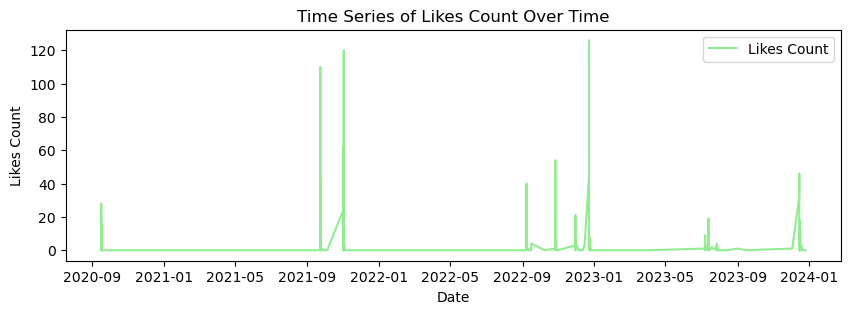

In [26]:
# 3.3 Time Series Plots
plt.figure(figsize=(10, 3))
plt.plot(df['date'], df['likesCount'], color='lightgreen', label='Likes Count')
plt.xlabel("Date")
plt.ylabel("Likes Count")
plt.title("Time Series of Likes Count Over Time")
plt.legend()
plt.show()

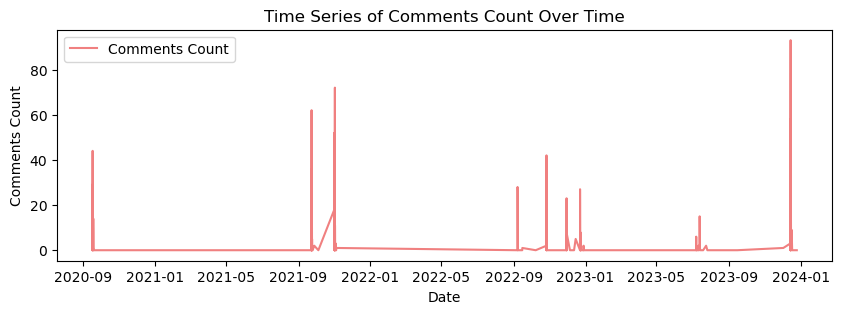

In [21]:
plt.figure(figsize=(10, 3))
plt.plot(df['date'], df['commentsCount'], color='lightcoral', label='Comments Count')
plt.xlabel("Date")
plt.ylabel("Comments Count")
plt.title("Time Series of Comments Count Over Time")
plt.legend()
plt.show()

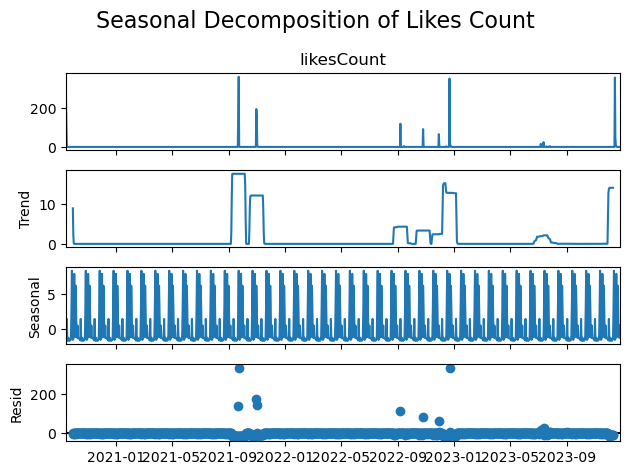

In [4]:
# 3.4 Seasonal Decomposition of Likes Count
# Ensure it's daily
df_daily = df.set_index('date').resample('D').sum()
df_daily.fillna(0, inplace=True)

decompose_result = seasonal_decompose(df_daily['likesCount'], model='additive', period=30)
decompose_result.plot()
plt.suptitle("Seasonal Decomposition of Likes Count", fontsize=16)
plt.tight_layout()
plt.show()

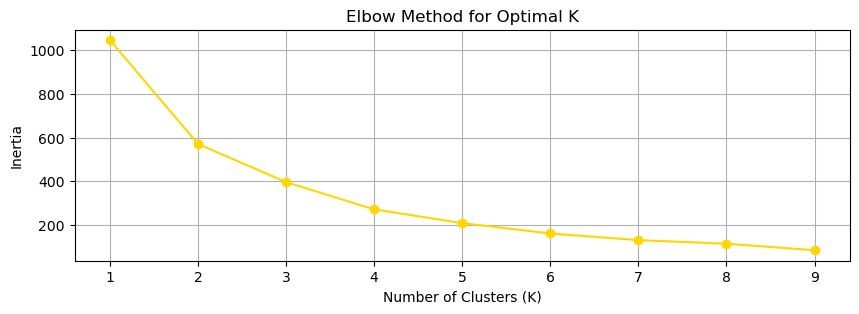

In [28]:
# Import all necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from matplotlib.colors import ListedColormap
# from sklearn.preprocessing import StandardScaler # You need this if 'scaled' isn't already created
import warnings
warnings.filterwarnings('ignore')

# --- 1. Data Preparation and Elbow Method ---

# Assuming 'df' is your DataFrame and 'scaled' is the standardized feature array.
# Example if features were not prepared:
# features = df[['likesCount', 'commentsCount']]
# scaler = StandardScaler()
# scaled = scaler.fit_transform(features)

# Elbow Plot Calculation
inertia = []
for k in range(1, 10):
    # n_init=10 is recommended for newer sklearn versions
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(scaled)
    inertia.append(km.inertia_)

# Elbow Plot Visualization (Color Change: marker='o', color='darkgreen')
plt.figure(figsize=(10, 3))
plt.plot(range(1, 10), inertia, marker='o', color='gold')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

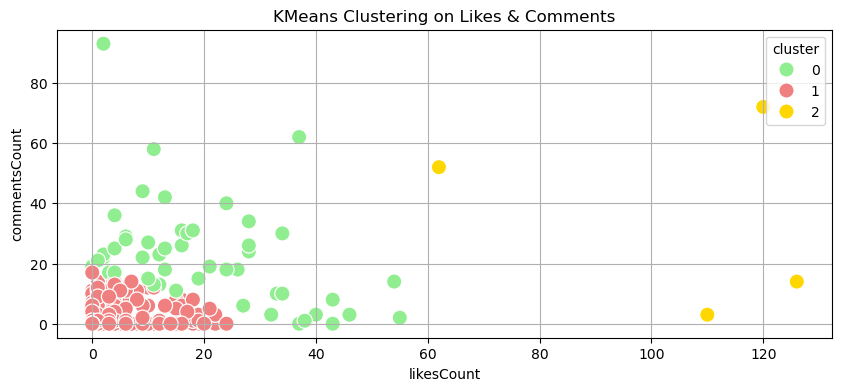

In [14]:
# --- 2. KMeans Clustering and Visualization ---

# Define the colors you want to use for the scatter plot
colors = ['lightgreen', 'lightcoral', 'gold']

# Apply KMeans with chosen cluster count (using k=3, as typically suggested by an elbow)
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
# FIX: The line below must be uncommented to create the 'cluster' column in df
df['cluster'] = kmeans.fit_predict(scaled)

# Visualize Clusters (Color Change: palette=colors)
plt.figure(figsize=(10, 4))
sns.scatterplot(
    data=df,
    x='likesCount',
    y='commentsCount',
    hue='cluster',
    s=120, # <-- Added: Increase the size of the data points
    palette=colors # Applied the custom color list
)
plt.title("KMeans Clustering on Likes & Comments")
plt.grid(True)
plt.show()

##### This scatter plot visualizes the results of KMeans Clustering (K=3) on data points based on their Likes Count (x-axis) and Comments Count (y-axis). 
The goal was to segment the data into three distinct groups.
The interpretation reveals three clusters that effectively separate the data based on magnitude and popularity:

- Cluster 0 (Light Green): This is the High Engagement group. It contains posts with a wide range of likes (from near 0 up to about 70) and the highest comments counts (ranging from about 10 up to 90). These posts are very active and popular, generating a lot of discussion relative to their likes.

- Cluster 1 (Light Coral): This is the Low Engagement/High Frequency group. It is heavily concentrated at the bottom left, representing posts with low likes (mostly under 30) and very low comments (mostly under 10). This likely represents the bulk of typical, low-performing posts.

- Cluster 2 (Gold/Yellow): This is the Extreme Outlier group. These are isolated points representing posts that are extremely popular, characterized by very high likes (over 100). Although the comments count varies within this cluster (from near 0 to about 70), they are clearly separated from the main body of data due to their exceptional like counts.